In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv("../data/raw/german_credit_data.csv")

print("=" * 60)
print("EXPLORACIÓN BÁSICA DEL DATASET")
print("=" * 60)

# Dimensiones
print(f"\n📊 Shape: {df.shape[0]} ejemplos, {df.shape[1]} características")

# Tipos de datos
print(f"\n📋 Tipos de datos:")
print(df.dtypes)

# Valores faltantes
print(f"\n❌ Valores faltantes:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ No hay valores faltantes")
else:
    print(missing[missing > 0])

# Estadísticas básicas
print(f"\n📈 Estadísticas básicas:")
print(df.describe())

# Variable objetivo (Target)
print(f"\n🎯 Distribución del Target:")
print(df['Target'].value_counts())
print(f"\nProporción:")
print((df['Target'].value_counts() / len(df) * 100).round(2))

EXPLORACIÓN BÁSICA DEL DATASET

📊 Shape: 1000 ejemplos, 21 características

📋 Tipos de datos:
Status                str
Duration            int64
Credit_History        str
Purpose               str
Credit_Amount       int64
Savings               str
Employment            str
Installment_Rate    int64
Personal_Status       str
Debtors               str
Residence_Since     int64
Property              str
Age                 int64
Other_Plans           str
Housing               str
Existing_Credits    int64
Job                   str
Dependents          int64
Telephone             str
Foreign_Worker        str
Target              int64
dtype: object

❌ Valores faltantes:
   ✅ No hay valores faltantes

📈 Estadísticas básicas:
          Duration  Credit_Amount  Installment_Rate  Residence_Since  \
count  1000.000000    1000.000000       1000.000000      1000.000000   
mean     20.903000    3271.258000          2.973000         2.845000   
std      12.058814    2822.736876          1.118715  

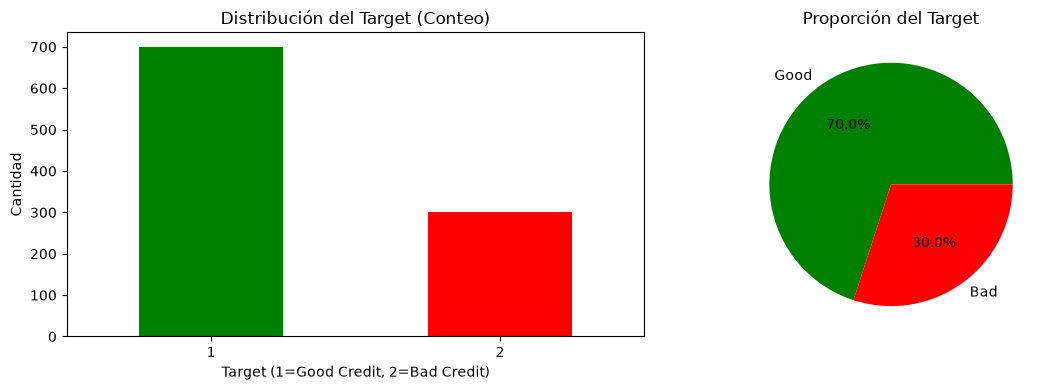

✅ El dataset tiene 700 créditos buenos y 300 créditos malos


In [8]:
# Visualizar la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de conteo
df['Target'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Distribución del Target (Conteo)')
axes[0].set_xlabel('Target (1=Good Credit, 2=Bad Credit)')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=0)

# Gráfico de proporción
df['Target'].value_counts(normalize=True).plot(kind='pie', ax=axes[1], 
                                                labels=['Good', 'Bad'], 
                                                autopct='%1.1f%%',
                                                colors=['green', 'red'])
axes[1].set_title('Proporción del Target')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"✅ El dataset tiene {len(df[df['Target'] == 1])} créditos buenos y {len(df[df['Target'] == 2])} créditos malos")

Características numéricas (8): ['Duration', 'Credit_Amount', 'Installment_Rate', 'Residence_Since', 'Age', 'Existing_Credits', 'Dependents', 'Target']

📈 Correlación con Target:
Target              1.000000
Duration            0.214927
Credit_Amount       0.154739
Installment_Rate    0.072404
Residence_Since     0.002967
Dependents         -0.003015
Existing_Credits   -0.045732
Age                -0.091127
dtype: float64


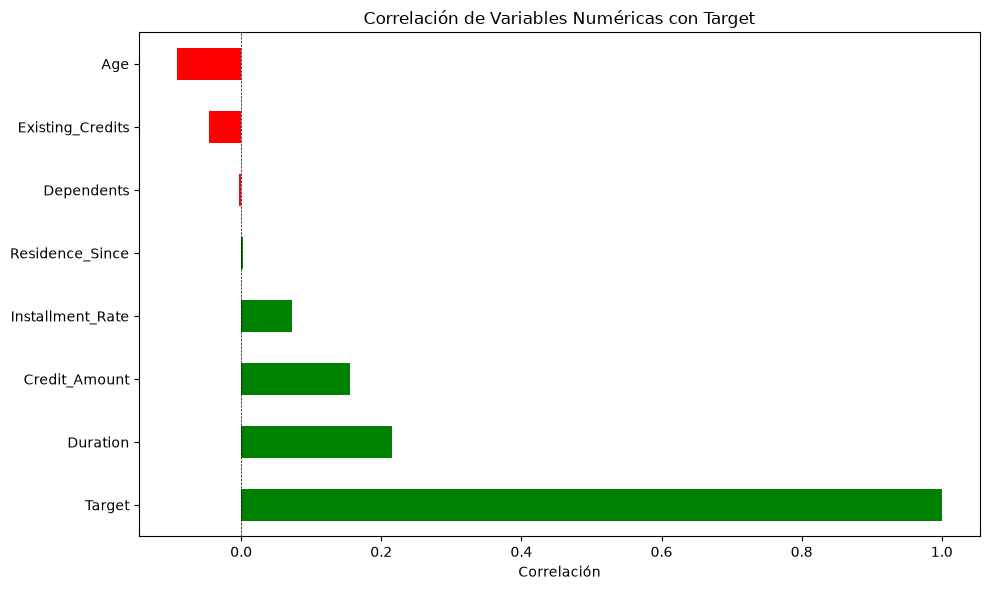

In [9]:
# Características numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Características numéricas ({len(numeric_cols)}): {numeric_cols}")

# Correlación con el target
print(f"\n📈 Correlación con Target:")
correlations = df[numeric_cols].corrwith(df['Target']).sort_values(ascending=False)
print(correlations)

# Visualizar correlaciones
plt.figure(figsize=(10, 6))
correlations.plot(kind='barh', color=['red' if x < 0 else 'green' for x in correlations.values])
plt.title('Correlación de Variables Numéricas con Target')
plt.xlabel('Correlación')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()